#Teste de conhecimento AVP1

**Discente:** Maria Taliciane Pereira da Silva

**Professor:** Alexandro Oliveira Alexandrino

**Disciplina:** Matemática Aplicada à Computação

**Data:** 25/09/2026

Este notebook tem como objetivo realizar o **Teste de conhecimento para a AVP1**, conforme as instruções fornecidas. Uma empresa de comércio eletrônico acompanha seus custos mensais de transporte e deseja analisar a variação desses custos e realizar uma previsão para os próximos meses.

## 1. Importação de Bibliotecas Essenciais

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurações para exibir gráficos com melhor qualidade
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## ETAPA 1 – Carregar os Dados

### 1.1 Obter os Dados Automaticamente

Disponibilizei o arquivo de dados base_custos_transporte.csv por meio de um link do Google Drive. O notebook realizará o download automático do arquivo durante a execução, permitindo que qualquer pessoa o utilize sem precisar montar o próprio Google Drive ou fazer o upload manual dos dados.

In [26]:
file_id = "1JsXcWzdib02ErUXQzJz4zTBioGR2THbw"
output_filename = "base_custos_transporte.csv"
url = f"https://drive.google.com/uc?id={file_id}"

print(f"Tentando baixar o arquivo '{output_filename}' do Google Drive...")

try:
    import gdown
except ImportError:
    print("gdown não encontrado, instalando...")
    %pip install gdown
    import gdown

if not os.path.exists(output_filename):
    try:
        gdown.download(url, output_filename, quiet=False)
        print("Download concluído com sucesso!")
    except Exception as e:
        raise RuntimeError(
            f"Não foi possível baixar o arquivo do Google Drive: {e}"
        ) from e
else:
    print("Arquivo já existe localmente, pulando o download.")

df = pd.read_csv(output_filename)
print("Arquivo carregado com sucesso!")
print(f"\nCaminho do arquivo carregado: ./{output_filename}")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
print(f"Nomes das colunas: {df.columns.tolist()}")
print("\nTabela completa dos dados:")
display(df)

Tentando baixar o arquivo 'base_custos_transporte.csv' do Google Drive...
Arquivo já existe localmente, pulando o download.
Arquivo carregado com sucesso!

Caminho do arquivo carregado: ./base_custos_transporte.csv
Quantidade de linhas: 12
Quantidade de colunas: 2
Nomes das colunas: ['mes', 'custo_transporte']

Tabela completa dos dados:


,mes,custo_transporte
0,1,44500
1,2,45200
2,3,48300
3,4,48600
4,5,51300
5,6,53300
6,7,53800
7,8,57000
8,9,57900
9,10,61000


### 1.2 Verificação de Colunas Essenciais

Nesta etapa, verifiquei se o arquivo possui as colunas essenciais `mes` e `custo_transporte`, necessárias para realizar os cálculos da análise. Também ajustei os tipos de dados dessas colunas para garantir que os valores estejam no formato numérico adequado e removi possíveis registros com valores inválidos ou ausentes.


In [27]:
if df is not None:
    required_columns = ['mes', 'custo_transporte']
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f"ERRO: As seguintes colunas essenciais estão ausentes: {missing_columns}.")
        print("Por favor, verifique o arquivo CSV.")
    else:
        print("Todas as colunas essenciais ('mes', 'custo_transporte') foram encontradas.")
        # Garantir que 'mes' seja numérico para cálculos futuros
        df['mes'] = pd.to_numeric(df['mes'], errors='coerce')
        # Garantir que 'custo_transporte' seja numérico
        df['custo_transporte'] = pd.to_numeric(df['custo_transporte'], errors='coerce')

        # Remover linhas com valores NaN após a conversão, se houver
        df.dropna(subset=['mes', 'custo_transporte'], inplace=True)
        print("Tipos de dados ajustados para 'mes' e 'custo_transporte'.")
else:
    print("Não foi possível verificar as colunas, pois o DataFrame não foi carregado.")

Todas as colunas essenciais ('mes', 'custo_transporte') foram encontradas.
Tipos de dados ajustados para 'mes' e 'custo_transporte'.


### 1.3 Resumo Estatístico do DataFrame

Nesta etapa, vou analisar um resumo estatístico dos dados presentes no DataFrame, observando informações como quantidade de registros, média, valores mínimo e máximo e outras medidas relevantes. Dessa forma, será possível compreender melhor a distribuição dos custos de transporte antes de realizar as demais análises.

In [13]:
if df is not None and not df.empty:
    print("Resumo Estatístico Completo do DataFrame:")
    display(df.describe())
else:
    print("Não foi possível exibir o resumo estatístico, pois o DataFrame está vazio ou não foi carregado.")

Resumo Estatístico Completo do DataFrame:


,mes,custo_transporte
count,12.000000,12.000000
mean,6.500000,53850.000000
std,3.605551,6490.482543
min,1.000000,44500.000000
25%,3.750000,48525.000000
50%,6.500000,53550.000000
75%,9.250000,58675.000000
max,12.000000,64000.000000


## ETAPA 2 – Identificação das Variáveis

Com base nos dados carregados, identifiquei as variáveis utilizadas na análise:

* **a) Variável independente:** A variável independente é o `mes`, pois representa o período de tempo em que os custos foram registrados. Ela será utilizada como referência para analisar a variação dos custos de transporte ao longo do tempo.

* **b) Variável dependente:** A variável dependente é o `custo_transporte`, pois representa o valor que será analisado e previsto. Seu comportamento é relacionado à passagem dos meses, representada pela variável independente.

* **c) Representação das variáveis no contexto do problema:**

  * O `mes` representa a sequência temporal dos registros dos custos de transporte. Por exemplo, o valor `1` corresponde ao primeiro mês analisado, o `2` ao segundo, e assim sucessivamente.
  * O `custo_transporte` representa o valor total gasto pela empresa de comércio eletrônico com transporte em cada mês. A análise dessa variável permite observar como os custos se comportam ao longo do período estudado.


## ETAPA 3 – Construir um Gráfico de Dispersão

### 3.1 Visualização dos Dados (Gráfico de Dispersão)

Para visualizar a relação entre o `mes` e o `custo_transporte`, criei um gráfico de dispersão. Isso me ajudou a identificar tendências ou padrões visuais nos dados.

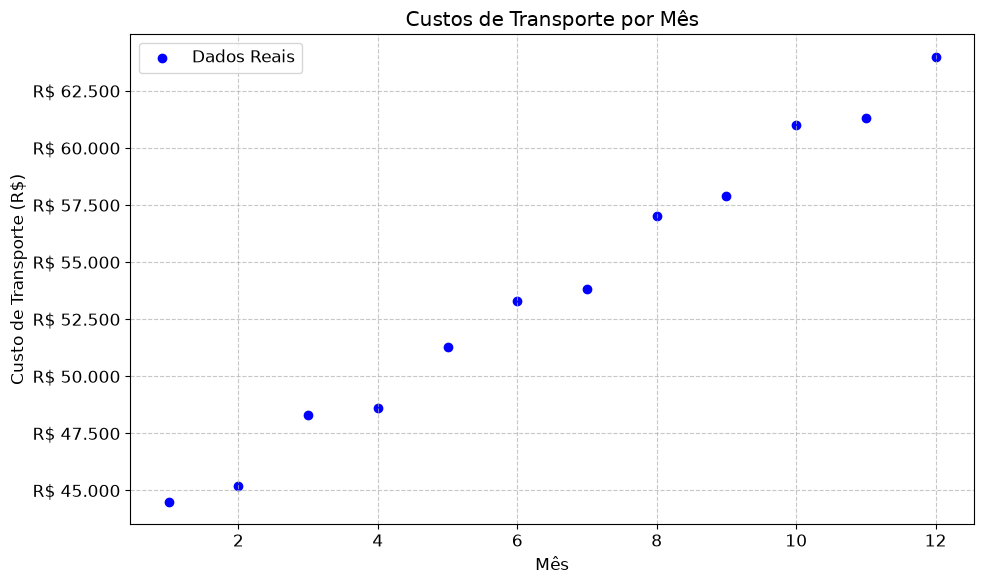

In [22]:
if df is not None and not df.empty:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['mes'], df['custo_transporte'], color='blue', label='Dados Reais')
    plt.title('Custos de Transporte por Mês')
    plt.xlabel('Mês')
    plt.ylabel('Custo de Transporte (R$)')
    plt.gca().yaxis.set_major_formatter(
        lambda value, _: f"R$ {value:,.0f}".replace(",", ".")
    )
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível gerar o gráfico de dispersão, pois o DataFrame está vazio ou não foi carregado.")

Observando o gráfico de dispersão, pude notar que os pontos, que representam os custos de transporte ao longo dos meses, parecem seguir uma tendência. Há uma clara inclinação ascendente, sugerindo que o custo de transporte tende a **aumentar** conforme os meses progridem. Os pontos não estão perfeitamente alinhados, indicando alguma variabilidade, mas a relação geral entre o mês e o custo parece ser aproximadamente linear e positiva.

### 3.2 Análise da Correlação

Nesta etapa, vou calcular o coeficiente de correlação de Pearson entre as variáveis `mes` e `custo_transporte`. Este valor indicará a força e a direção da relação linear entre o tempo (mês) e o custo de transporte, ajudando a quantificar a tendência observada nos dados.

In [15]:
if df is not None and not df.empty:
    correlation = df['mes'].corr(df['custo_transporte'])
    print(f"A correlação entre 'mes' e 'custo_transporte' é: {correlation:.4f}")
    print("\nInterpretação da Correlação:")
    if correlation > 0.7:
        print("Existe uma forte correlação positiva, indicando que à medida que o mês avança, o custo de transporte tende a aumentar significativamente.")
    elif correlation < -0.7:
        print("Existe uma forte correlação negativa, indicando que à medida que o mês avança, o custo de transporte tende a diminuir significativamente.")
    elif correlation > 0.3:
        print("Existe uma correlação positiva moderada, indicando que há uma tendência de aumento do custo de transporte com o avanço do mês, mas com alguma variabilidade.")
    elif correlation < -0.3:
        print("Existe uma correlação negativa moderada, indicando que há uma tendência de diminuição do custo de transporte com o avanço do mês, mas com alguma variabilidade.")
    else:
        print("Existe uma correlação fraca, indicando que a relação linear entre o mês e o custo de transporte não é muito pronunciada.")
else:
    print("Não foi possível calcular a correlação, pois o DataFrame está vazio ou não foi carregado.")

A correlação entre 'mes' e 'custo_transporte' é: 0.9953

Interpretação da Correlação:
Existe uma forte correlação positiva, indicando que à medida que o mês avança, o custo de transporte tende a aumentar significativamente.


## ETAPA 4 – Encontrar uma Função Afim

Vamos encontrar uma função afim do tipo `f(x) = ax + b` que represente o comportamento dos custos de transporte. Para isso, utilizaremos uma regressão linear, que nos permitirá calcular os coeficientes `a` (coeficiente angular) e `b` (coeficiente linear) a partir dos dados existentes. O `numpy.polyfit` é uma ferramenta adequada para isso, ajustando um polinômio de grau 1 aos nossos dados (o que corresponde a uma função afim).

In [28]:
if df is not None and not df.empty:
    # Garantir que 'mes' e 'custo_transporte' sejam de tipos numéricos
    x = df['mes'].astype(float)
    y = df['custo_transporte'].astype(float)

    # Calcular os coeficientes 'a' e 'b' usando regressão linear (polinômio de grau 1)
    a, b = np.polyfit(x, y, 1)

    print(f"Valor do coeficiente 'a': {a:.4f}")
    print(f"Valor do coeficiente 'b': {b:.4f}")
    print(f"\nFunção encontrada: f(x) = {a:.4f}x + {b:.4f}")

    # Armazenar os valores originais para cálculos posteriores
    a_original = a
    b_original = b

else:
    a_original = None
    b_original = None
    print("Não foi possível calcular a função afim, pois o DataFrame está vazio ou não foi carregado.")

Valor do coeficiente 'a': 1791.6084
Valor do coeficiente 'b': 42204.5455

Função encontrada: f(x) = 1791.6084x + 42204.5455


Os coeficientes `a` e `b` foram obtidos através do método de Mínimos Quadrados Ordinários (MQO), implementado pela função `numpy.polyfit`. Este método busca a reta que minimiza a soma dos quadrados das distâncias verticais entre os pontos de dados reais e a reta ajustada. O coeficiente `a` representa a inclinação da reta, indicando a taxa de variação do custo de transporte por mês, e `b` representa o ponto onde a reta cruza o eixo Y, ou seja, o custo de transporte quando o mês é zero (embora o mês zero possa não ter um significado prático direto neste contexto, serve como intercepto da função).

## ETAPA 5 – Interpretar a Função

Vou interpretar os coeficientes `a` e `b` no contexto do problema dos custos de transporte, relacionando cada coeficiente ao comportamento dos custos ao longo dos meses.

In [17]:
if a_original is not None and b_original is not None:
    print("a) O que representa o coeficiente 'a' no contexto do problema?\n")
    print(f"O coeficiente a ({a_original:.2f}) representa a taxa média de variação do custo de transporte por mês.")

    print("\nb) O que representa o coeficiente 'b'?\n")
    print(f"O coeficiente b ({b_original:.2f}) representa o intercepto da reta, isto é, o custo estimado para o mês zero. Esse mês não foi observado; o valor é parte do modelo matemático.")

    print("\nc) O valor de 'a' indica crescimento ou redução dos custos?\n")
    if a_original > 0:
        print(f"Como a é positivo, o modelo indica crescimento médio dos custos ao longo dos meses.")
    elif a_original < 0:
        print("Como a é negativo, o modelo indica redução média dos custos ao longo dos meses.")
    else:
        print("Como a é zero, o modelo indica custos constantes ao longo dos meses.")
else:
    raise RuntimeError("Não foi possível interpretar a função: os coeficientes não foram calculados.")

a) O que representa o coeficiente 'a' no contexto do problema?

O coeficiente a (1791.61) representa a taxa média de variação do custo de transporte por mês.

b) O que representa o coeficiente 'b'?

O coeficiente b (42204.55) representa o intercepto da reta, isto é, o custo estimado para o mês zero. Esse mês não foi observado; o valor é parte do modelo matemático.

c) O valor de 'a' indica crescimento ou redução dos custos?

Como a é positivo, o modelo indica crescimento médio dos custos ao longo dos meses.


## ETAPA 6 – Representar a Função Graficamente

Agora, foi possível visualizar a função afim encontrada junto aos dados reais em um novo gráfico. Dessa forma, podemos observar o quanto a reta ajustada representa a tendência dos custos de transporte ao longo dos meses.

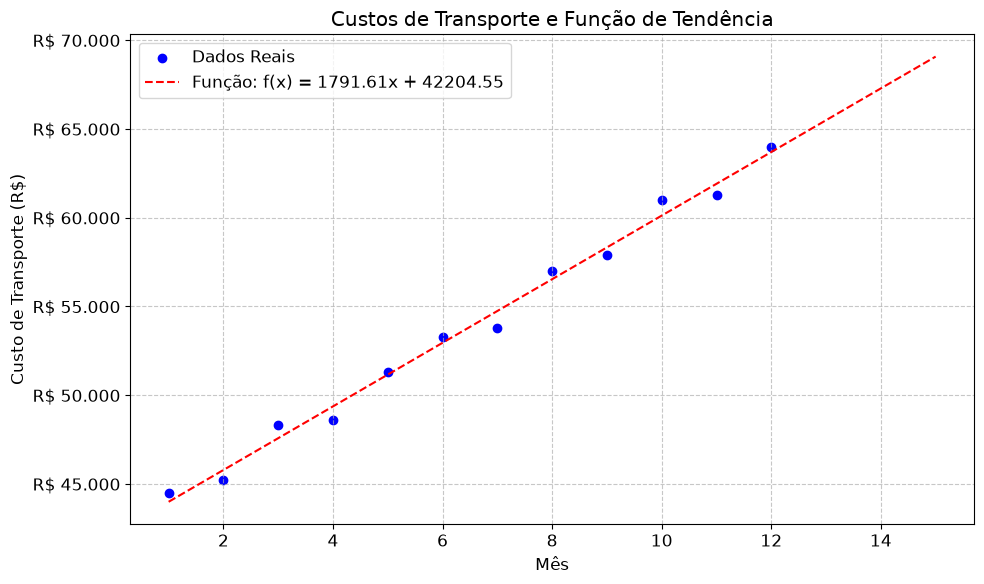

In [23]:
if df is not None and not df.empty and a_original is not None and b_original is not None:
    plt.figure(figsize=(10, 6))

    plt.scatter(df['mes'], df['custo_transporte'], color='blue', label='Dados Reais')

    meses_para_reta = np.linspace(df['mes'].min(), df['mes'].max() + 3, 100)
    custos_projetados = a_original * meses_para_reta + b_original
    plt.plot(
        meses_para_reta,
        custos_projetados,
        color='red',
        linestyle='--',
        label=f'Função: f(x) = {a_original:.2f}x + {b_original:.2f}',
    )

    plt.title('Custos de Transporte e Função de Tendência')
    plt.xlabel('Mês')
    plt.ylabel('Custo de Transporte (R$)')
    plt.gca().yaxis.set_major_formatter(
        lambda value, _: f"R$ {value:,.0f}".replace(",", ".")
    )
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível gerar o gráfico com a função, pois o DataFrame ou os coeficientes estão ausentes.")

## ETAPA 7 – Fazer Previsões

Vou utilizar a função afim encontrada para estimar os custos de transporte dos próximos meses, considerando os meses 13, 14 e 15. Essas previsões são estimativas baseadas na tendência observada nos dados e podem apresentar diferenças em relação aos valores reais, principalmente caso ocorram mudanças no comportamento dos custos ao longo do tempo.


In [32]:
if a_original is not None and b_original is not None:
    # Função para calcular o custo estimado
    def f(x):
        return a_original * x + b_original

    # Meses para previsão
    meses_previsao = [13, 14, 15]

    print("Cálculos das previsões:")
    for mes in meses_previsao:
        custo_estimado = f(mes)
        print(f"f({mes}) = {a_original:.2f} × {mes} + {b_original:.2f} = {custo_estimado:.2f}")

    # Criar tabela de previsão
    previsoes = {'Mês': meses_previsao, 'Custo estimado (R$)': [f(mes) for mes in meses_previsao]}
    df_previsoes = pd.DataFrame(previsoes)

    # Formatar como moeda brasileira
    df_previsoes['Custo estimado (R$)'] = df_previsoes['Custo estimado (R$)'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

    print("\nPrevisões para os próximos meses:")
    display(df_previsoes.set_index('Mês'))
else:
    print("Não foi possível fazer as previsões, pois os coeficientes 'a' e 'b' não foram calculados.")

Cálculos das previsões:
f(13) = 1791.61 × 13 + 42204.55 = 65495.45
f(14) = 1791.61 × 14 + 42204.55 = 67287.06
f(15) = 1791.61 × 15 + 42204.55 = 69078.67

Previsões para os próximos meses:


,Custo estimado (R$)
Mês,
13,"R$ 65.495,45"
14,"R$ 67.287,06"
15,"R$ 69.078,67"


## ETAPA 8 – Analisar o Resultado

Nesta etapa, vou analisar a qualidade da função encontrada e o comportamento geral dos custos, comparando a função com os dados observados e calculando uma medida objetiva, como o R², para avaliar o quanto a função representa os dados.

In [30]:
if df is not None and not df.empty and a_original is not None and b_original is not None:
    y_pred = a_original * df['mes'] + b_original

    ss_total = ((df['custo_transporte'] - df['custo_transporte'].mean()) ** 2).sum()
    ss_residual = ((df['custo_transporte'] - y_pred) ** 2).sum()
    r_squared = 1 - (ss_residual / ss_total) if ss_total != 0 else 0

    r_squared_percent = f"{r_squared:.2%}".replace(".", ",")
    print("a) A função encontrada representa bem a tendência dos dados?\n")
    print(f"O coeficiente de determinação R² é {r_squared:.4f} ({r_squared_percent}).")
    print(f"Para estes dados, a reta explica {r_squared_percent} da variabilidade observada nos custos.")
    if r_squared >= 0.9:
        print("Com base nesse valor, a função representa muito bem a tendência dos dados analisados.")
    elif r_squared >= 0.7:
        print("Com base nesse valor, a função representa razoavelmente a tendência dos dados analisados.")
    else:
        print("Com base nesse valor, a função representa pouco a tendência dos dados analisados.")

    print("\nb) Os custos estão aumentando ou diminuindo?\n")
    if a_original > 0:
        print("Como o coeficiente angular é positivo, os custos apresentam tendência de aumento.")
    elif a_original < 0:
        print("Como o coeficiente angular é negativo, os custos apresentam tendência de diminuição.")
    else:
        print("Como o coeficiente angular é zero, os custos permanecem constantes segundo a função.")

    print("\nc) Aproximadamente quanto o custo aumenta a cada mês?\n")
    if a_original > 0:
        print(f"O custo aumenta aproximadamente R$ {a_original:.2f} por mês, segundo o coeficiente angular.")
    elif a_original < 0:
        print(f"O custo diminui aproximadamente R$ {abs(a_original):.2f} por mês, segundo o coeficiente angular.")
    else:
        print("A função não indica aumento ou diminuição mensal do custo.")

    print("\nComparação entre valores observados, ajustados e previstos:")
    print("Os dados observados apresentam variações mensais, enquanto a função afim resume a tendência geral por uma reta.")
    print(f"A função ajustada é f(x) = {a_original:.2f}x + {b_original:.2f}.")
    print("As previsões para os meses 13, 14 e 15 são projeções da tendência observada, não garantias de valores futuros.")
else:
    raise RuntimeError("Não foi possível analisar os resultados: faltam dados ou coeficientes calculados.")

a) A função encontrada representa bem a tendência dos dados?

O coeficiente de determinação R² é 0.9905 (99,05%).
Para estes dados, a reta explica 99,05% da variabilidade observada nos custos.
Com base nesse valor, a função representa muito bem a tendência dos dados analisados.

b) Os custos estão aumentando ou diminuindo?

Como o coeficiente angular é positivo, os custos apresentam tendência de aumento.

c) Aproximadamente quanto o custo aumenta a cada mês?

O custo aumenta aproximadamente R$ 1791.61 por mês, segundo o coeficiente angular.

Comparação entre valores observados, ajustados e previstos:
Os dados observados apresentam variações mensais, enquanto a função afim resume a tendência geral por uma reta.
A função ajustada é f(x) = 1791.61x + 42204.55.
As previsões para os meses 13, 14 e 15 são projeções da tendência observada, não garantias de valores futuros.


## ETAPA 9 – Conclusão

Com base nos dados analisados, concluo que a empresa pode esperar uma tendência de aumento dos custos de transporte nos próximos meses, caso o comportamento observado se mantenha. Ajustei aos dados a função afim `f(x) = 1791,6084x + 42204,5455`, cujo coeficiente angular indica um aumento médio aproximado de **R$ 1.791,61 por mês**. As previsões calculadas para os meses 13, 14 e 15 são, respectivamente, **R$ 65.495,45**, **R$ 67.287,06** e **R$ 69.078,67**. Essas estimativas representam uma projeção matemática da tendência histórica e podem diferir dos custos efetivamente realizados.

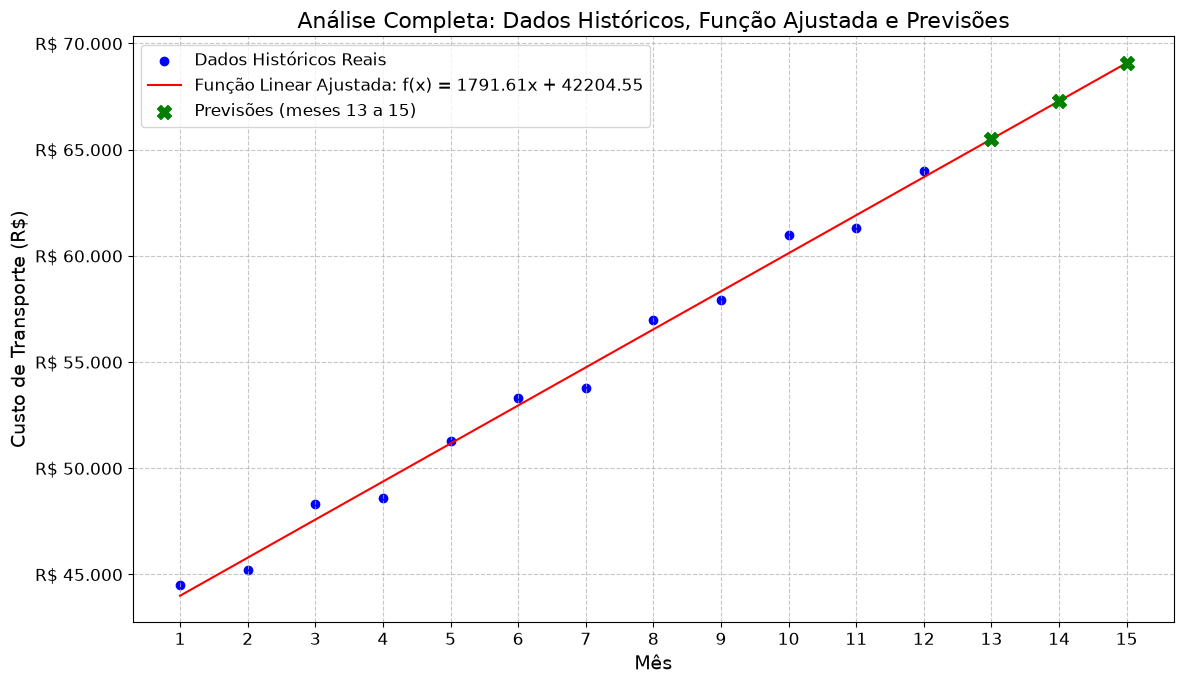

In [25]:
if df is not None and not df.empty and a_original is not None and b_original is not None:
    plt.figure(figsize=(12, 7))

    plt.scatter(
        df['mes'],
        df['custo_transporte'],
        color='blue',
        label='Dados Históricos Reais',
    )

    meses_para_reta_completa = np.linspace(df['mes'].min(), 15, 100)
    custos_projetados_reta = a_original * meses_para_reta_completa + b_original
    plt.plot(
        meses_para_reta_completa,
        custos_projetados_reta,
        color='red',
        linestyle='-',
        label=f'Função Linear Ajustada: f(x) = {a_original:.2f}x + {b_original:.2f}',
    )

    meses_previsao_pts = [13, 14, 15]
    custos_previsao_pts = [
        a_original * mes + b_original for mes in meses_previsao_pts
    ]
    plt.scatter(
        meses_previsao_pts,
        custos_previsao_pts,
        color='green',
        marker='X',
        s=100,
        label='Previsões (meses 13 a 15)',
        zorder=5,
    )

    plt.title('Análise Completa: Dados Históricos, Função Ajustada e Previsões', fontsize=16)
    plt.xlabel('Mês', fontsize=14)
    plt.ylabel('Custo de Transporte (R$)', fontsize=14)
    plt.gca().yaxis.set_major_formatter(
        lambda value, _: f"R$ {value:,.0f}".replace(",", ".")
    )
    plt.xticks(np.arange(1, 16, 1))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    raise RuntimeError(
        "Não foi possível gerar o gráfico de conclusão: faltam dados ou coeficientes."
    )